In [1]:
from numpy import array, linspace, sqrt, cbrt, power, reshape, column_stack, zeros
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [16]:
tol = 1e-6
j, k = 0, 1.5
# j, k = 1, 2
eps = 0.25
#De = 6.334
De = 1.0
ag = sqrt(eps)*De
ag2 = ag**2

In [17]:
b = 8*(3+j)*k**2/(5+j)*ag2
u0_u = k*(1+4*k**2*ag2)/(1+b)
delta = sqrt(27*b+4) + sqrt(27*b)
un_u = power(432,1/6)*(power(delta,2/3)-power(2,2/3))/(6*sqrt(b)*power(delta,1/3))
u0 = k*un_u*(1+4*k**2*ag2*(un_u**2))
print(un_u)
print(u0)
print(u0/un_u)

0.5502281770942108
1.3875570442735523
2.521784783180911


In [18]:
def Iu(x, ag, beta, k=1.5):
    ag2 = ag**2
    A = 1/(6.0*ag2*beta)
    C = -k*x*3.0*A

    sac = sqrt(A**3 + C**2)
    Fp = cbrt(C + sac)
    Fm = cbrt(C - sac)
    Gp = 3*C + sac
    Gm = 3*C - sac

    Ic = Fp*Gm + Fm*Gp
    Ip = Fp*(8*A**3 + C*(-19*C+9*sac)) - 8*power(A,3.5)
    Im = Fm*(8*A**3 + C*(-19*C-9*sac)) + 8*power(A,3.5)

    mp_ms = (1.0-beta)/beta
    I = x/beta + 3.0/(8*C)*mp_ms*Ic + 9.0/(280.0*C**2)*mp_ms*(Ip + Im)

    return I - 1.0

In [19]:

def calc_un_u(ag, beta, k=1.5):
    ag2 = ag**2
    if(beta < tol):
        b = 8*(3+j)*k**2/(5+j)*ag2
        delta = sqrt(27*b+4) + sqrt(27*b)
        un_u = power(432,1/6)*(power(delta,2/3)-power(2,2/3))/(6*sqrt(b)*power(delta,1/3))
    elif(beta > 1-tol):
        un_u = 1.0
    else:
        un_u = fsolve(Iu, 0.5, args=(ag, beta, k))[0]

    return un_u

In [20]:
beta_vals = array([0.0, 0.01, 0.1, 0.5, 0.8])
num_ag_vals = 100
ag_vals = linspace(10.0/num_ag_vals, 10.0, num_ag_vals)

un_u_vals = zeros((num_ag_vals, len(beta_vals)))

for i, ag in enumerate(ag_vals):
    for j, beta in enumerate(beta_vals):
        un_u_vals[i,j] = calc_un_u(ag, beta)

# print(un_u_vals)

Text(0, 0.5, '$u_n/u$')

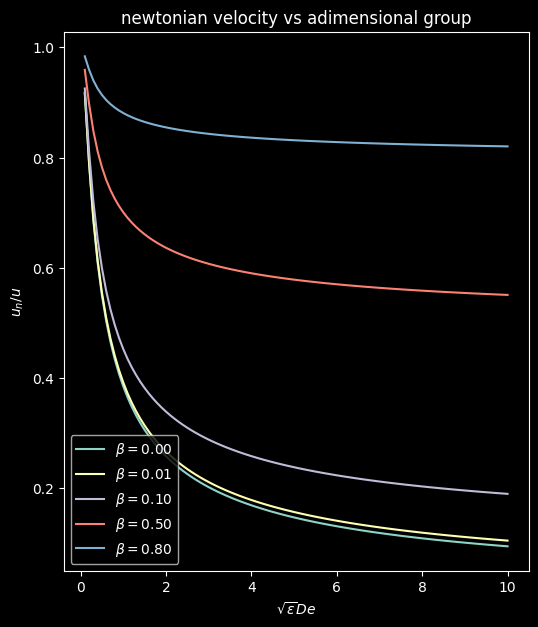

In [21]:
fig, ax = plt.subplots(figsize=(6,7))
for j, beta in enumerate(beta_vals):
    ax.plot(ag_vals, un_u_vals[:,j], label=r'$\beta = %.2f$' % beta)
ax.legend()
ax.set_title("newtonian velocity vs adimensional group")
ax.set_xlabel(r'$\sqrt{\epsilon}De$')
ax.set_ylabel(r'$u_n/u$')

In [22]:
def calc_u(y, ag, beta, k=1.5):

    un_u = calc_un_u(ag, beta, k=k)

    ag2 = ag**2
    if(beta < tol):
        uy_u = k*un_u*(1.0 - y**2)*(1.0 + 4.0*ag2*(k*un_u)**2*(1.0 + y**2))
    elif(beta > 1-tol):
        uy_u = k*un_u*(1.0 - y**2)
    else: 
        A = 1/(6.0*ag2*beta)
        C = -k*un_u*3.0*A
        sac = sqrt(A**3 + C**2)
        sacy = sqrt(A**3 + (C*y)**2)

        Fp = cbrt(C + sac)
        Fm = cbrt(C - sac)
        Gp = 3*C + sac
        Gm = 3*C - sac
        Fyp = cbrt(C*y + sacy)
        Fym = cbrt(C*y - sacy)
        Gyp = 3*C*y + sacy
        Gym = 3*C*y - sacy

        mp_ms = (1.0-beta)/beta
        uy_u = k*un_u/beta * (1.0 - y**2) + 3.0/(8.0*C)*mp_ms*(Fp*Gm - Fyp*Gym + Fm*Gp - Fym*Gyp)
    return uy_u

In [23]:
def calc_t(model, y, De, model_par, beta, Re, k=1.5):
    if(model=='ptt'):
        eps = model_par 
        a = 1.0
        ag = sqrt(eps)*De
    elif(model=='fene_p'): 
        L2 = model_par
        a = L2/(L2-3)
        ag = sqrt(1/L2)*(De/a)
    else:
        print('Model not implemented')
        return
    un_u = calc_un_u(ag, beta, k=k)

    if(beta > 1-tol):
        txy = 0.0
        txx = 0.0
    else:
        if(beta<tol):
            txy = -2*k*un_u*y
            
        else:
            ag2 = ag**2
            A = 1/(6.0*ag2*beta)
            C = -k*un_u*3.0*A
            sacy = sqrt(A**3 + (C*y)**2)

            Fyp = cbrt(C*y + sacy)
            Fym = cbrt(C*y - sacy)

            txy = Fyp + Fym
        
        txx = 2.0*(De/a)/(1-beta)*(txy**2)

    return txx/Re, txy/Re

In [24]:
De, eps = 5.0, 0.05
Re = 4.8
ag = sqrt(eps)*De

for j, beta in enumerate(beta_vals):
        print(r'beta = %.2f | ' % beta, r'un_u = %.8f | ' % calc_un_u(ag, beta))

beta = 0.00 |  un_u = 0.14674768 | 
beta = 0.01 |  un_u = 0.15660238 | 
beta = 0.10 |  un_u = 0.23789701 | 
beta = 0.50 |  un_u = 0.57842490 | 
beta = 0.80 |  un_u = 0.83147996 | 


In [25]:
y = linspace(-1, 1, 64)
uy_u_vals = zeros((len(y), len(beta_vals)))
txx_vals = zeros((len(y), len(beta_vals)))
txy_vals = zeros((len(y), len(beta_vals)))
for j, beta in enumerate(beta_vals):
    uy_u_vals[:,j] = calc_u(y, ag, beta)
    txx_vals[:,j], txy_vals[:,j] = calc_t('ptt', y, De, eps, beta, Re)
    u0_u = calc_u(0, ag, beta)
    print(r'beta = %.2f | ' % beta, r'u0_u = %.8f | ' % u0_u)

beta = 0.00 |  u0_u = 1.28668692 | 
beta = 0.01 |  u0_u = 1.30239406 | 
beta = 0.10 |  u0_u = 1.38075706 | 
beta = 0.50 |  u0_u = 1.47197636 | 
beta = 0.80 |  u0_u = 1.49214104 | 


In [12]:
for j, beta in enumerate(beta_vals):
    with open(f"fields_analytical/ptt_u_beta{beta}.txt", 'w') as file:
        file.write('y, u\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {uy_u_vals[i,j]}\n')
    with open(f"fields_analytical/ptt_txx_beta{beta}.txt", 'w') as file:
        file.write('y, txx\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {txx_vals[i,j]}\n')
    with open(f"fields_analytical/ptt_txy_beta{beta}.txt", 'w') as file:
        file.write('y, txy\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {txy_vals[i,j]}\n')

Text(0, 0.5, 'u')

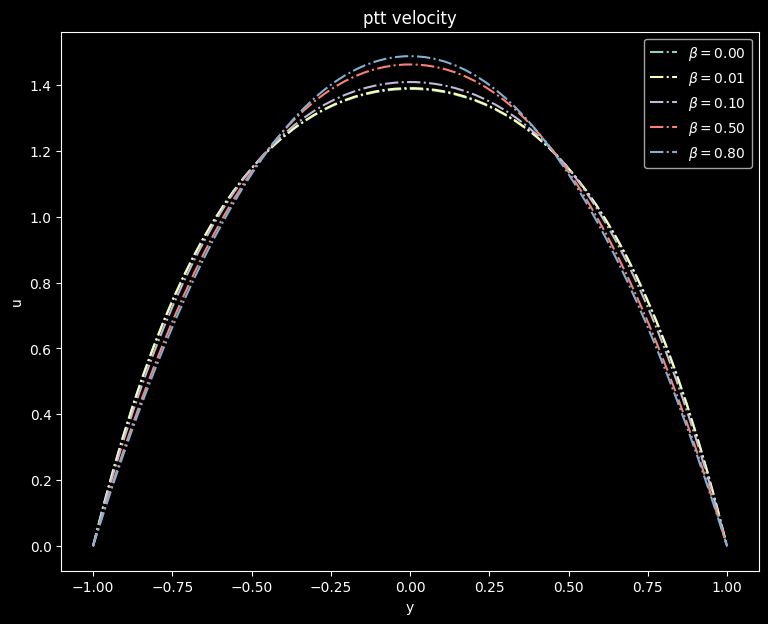

In [13]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, uy_u_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
#ax.plot(y, k*(1-y**2), label=r'newt' % beta, linestyle='-')
ax.legend()
ax.set_title('ptt velocity')
ax.set_xlabel('y')
ax.set_ylabel('u')

Text(0, 0.5, 'txx')

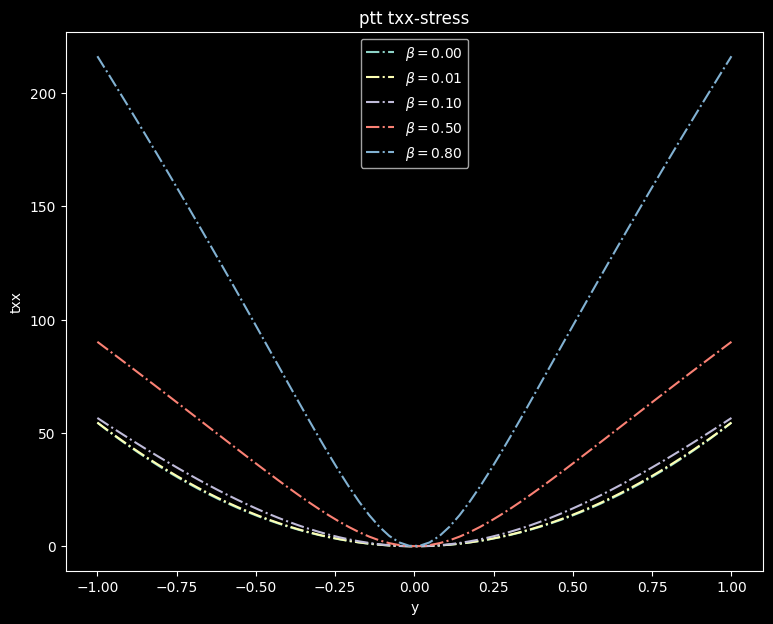

In [14]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, txx_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
ax.legend()
ax.set_title('ptt txx-stress')
ax.set_xlabel('y')
ax.set_ylabel('txx')

Text(0, 0.5, 'txy')

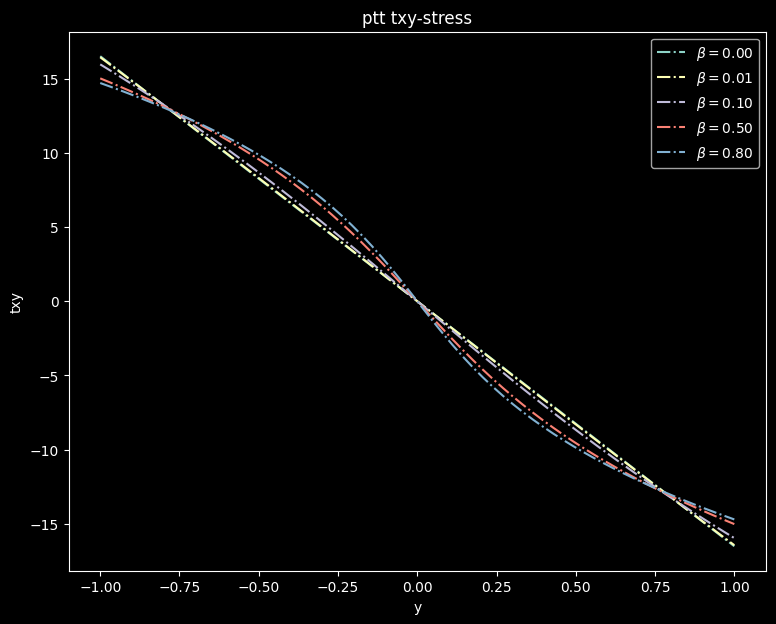

In [15]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, txy_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
ax.legend()
ax.set_title('ptt txy-stress')
ax.set_xlabel('y')
ax.set_ylabel('txy')

In [17]:
De, L2 = 2.0, 100.0
a = L2/(L2-3)
ag = sqrt(1/L2)*(De/a)

for j, beta in enumerate(beta_vals):
        print(r'beta = %.2f | ' % beta, r'un_u = %.2f | ' % calc_un_u(ag, beta))

beta = 0.00 |  un_u = 0.80 | 
beta = 0.01 |  un_u = 0.80 | 
beta = 0.10 |  un_u = 0.82 | 
beta = 0.50 |  un_u = 0.90 | 
beta = 0.80 |  un_u = 0.96 | 


In [18]:
for j, beta in enumerate(beta_vals):
    uy_u_vals[:,j] = calc_u(y, ag, beta)
    txx_vals[:,j], txy_vals[:,j] = calc_t('fene_p', y, De, L2, beta, Re)
    u0_u = calc_u(0, ag, beta)
    print(r'beta = %.2f | ' % beta, r'u0_u = %.8f | ' % u0_u)

beta = 0.00 |  u0_u = 1.44885809 | 
beta = 0.01 |  u0_u = 1.44956526 | 
beta = 0.10 |  u0_u = 1.45565743 | 
beta = 0.50 |  u0_u = 1.47827993 | 
beta = 0.80 |  u0_u = 1.49196846 | 


In [18]:
for j, beta in enumerate(beta_vals):
    with open(f"fields_analytical/fene_p_u_beta{beta}.txt", 'w') as file:
        file.write('y, u\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {uy_u_vals[i,j]}\n')
    with open(f"fields_analytical/fene_p_txx_beta{beta}.txt", 'w') as file:
        file.write('y, txx\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {txx_vals[i,j]}\n')
    with open(f"fields_analytical/fene_p_txy_beta{beta}.txt", 'w') as file:
        file.write('y, txy\n')  # Header
        for i in range(len(y)):
            file.write(f'{y[i]}, {txy_vals[i,j]}\n')

Text(0, 0.5, 'u')

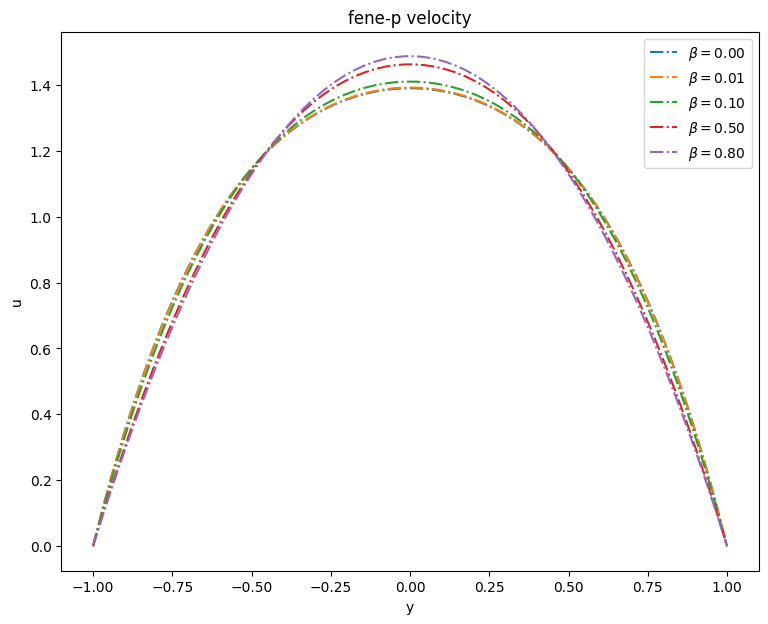

In [19]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, uy_u_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
#ax.plot(y, k*(1-y**2), label=r'newt' % beta, linestyle='-')
ax.legend()
ax.set_title('fene-p velocity')
ax.set_xlabel('y')
ax.set_ylabel('u')

Text(0, 0.5, 'txx')

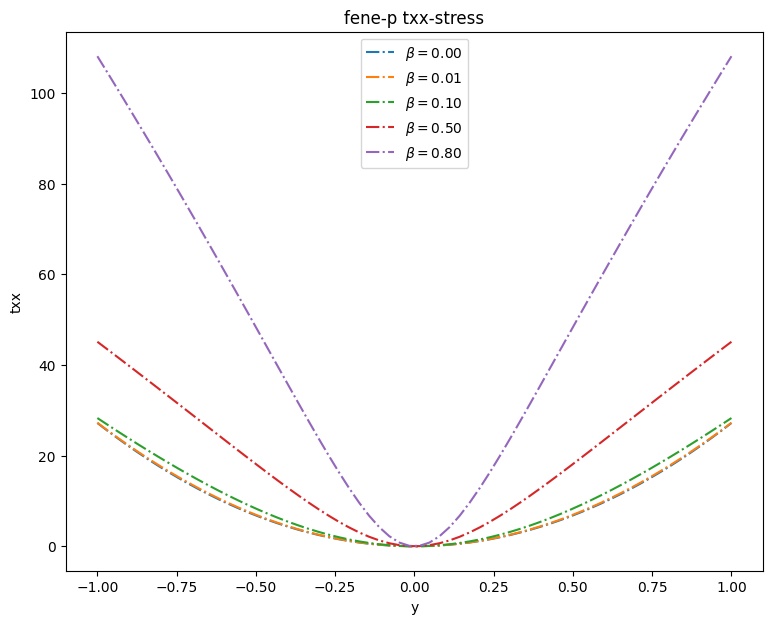

In [20]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, txx_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
ax.legend()
ax.set_title('fene-p txx-stress')
ax.set_xlabel('y')
ax.set_ylabel('txx')

Text(0, 0.5, 'txy')

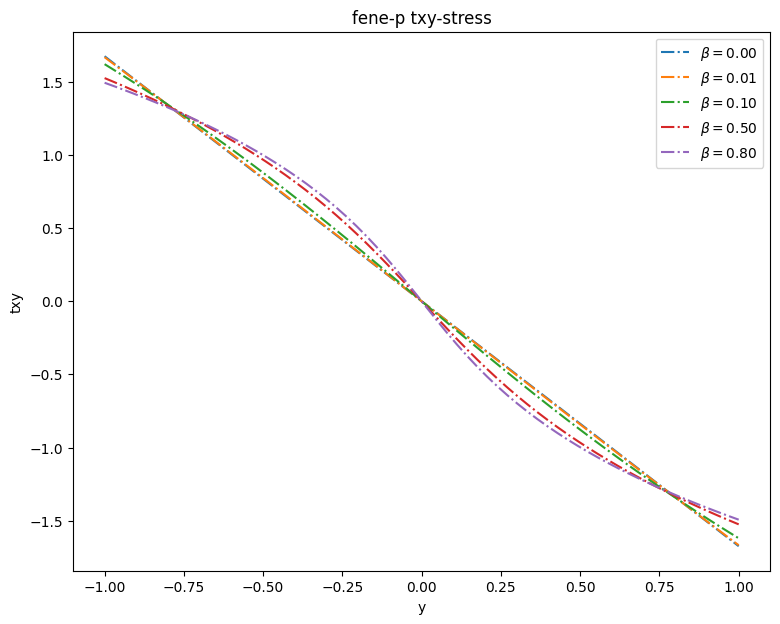

In [21]:
fig, ax = plt.subplots(figsize=(9,7))
for j, beta in enumerate(beta_vals):
    ax.plot(y, txy_vals[:,j], label=r'$\beta = %.2f$' % beta, linestyle='-.')
ax.legend()
ax.set_title('fene-p txy-stress')
ax.set_xlabel('y')
ax.set_ylabel('txy')